In [7]:
"""
Simple Stroke Prediction Model Training
Single file that does everything: load data, train, save model
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

Using device: cuda



In [9]:
class StrokeNN(nn.Module):
    def __init__(self, input_size=16):
        super(StrokeNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(32, 16)
        self.bn4 = nn.BatchNorm1d(16)
        self.dropout4 = nn.Dropout(0.2)
        self.fc5 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.dropout1(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout3(self.relu(self.bn3(self.fc3(x))))
        x = self.dropout4(self.relu(self.bn4(self.fc4(x))))
        return self.fc5(x)


In [10]:
print("="*70)
print("LOADING DATA")
print("="*70)

df = pd.read_csv('stroke_risk_dataset_v2.csv')
print(f"✓ Loaded {len(df)} records")
print(f"✓ Columns: {df.columns.tolist()}\n")

# Find target column
target_col = 'at_risk'  # Change this if your target column has a different name
print(f"Target column: {target_col}")
print(f"Target distribution:\n{df[target_col].value_counts()}\n")

# Separate features and target
exclude_cols = [col for col in df.columns if 'risk' in col.lower()]
X = df.drop(columns=exclude_cols)
y = df[target_col]

# Handle categorical variables (like gender)
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

feature_names = X.columns.tolist()
print(f"✓ Features: {len(feature_names)}")
print(f"✓ Feature names: {feature_names}\n")


print("="*70)
print("SPLITTING DATA")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)} samples")
print(f"Testing: {len(X_test)} samples\n")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.FloatTensor(y_train)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.FloatTensor(y_test)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)



LOADING DATA
✓ Loaded 35000 records
✓ Columns: ['age', 'gender', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'swelling_edema', 'neck_jaw_pain', 'excessive_sweating', 'persistent_cough', 'nausea_vomiting', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'anxiety_doom', 'stroke_risk_percentage', 'at_risk']

Target column: at_risk
Target distribution:
at_risk
0    22113
1    12887
Name: count, dtype: int64

✓ Features: 17
✓ Feature names: ['age', 'gender', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'swelling_edema', 'neck_jaw_pain', 'excessive_sweating', 'persistent_cough', 'nausea_vomiting', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'anxiety_doom']

SPLITTING DATA
Training: 28000 samples
Testing: 7000 samples



In [11]:
# 1) DATA LOADING & EXPLORATION FUNCTIONS
df = pd.read_csv('stroke_risk_dataset_v2.csv')

In [12]:
print("="*70)
print("TRAINING MODEL")
print("="*70)

model = StrokeNN(input_size=len(feature_names)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print(f"Training for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        predicted = (torch.sigmoid(outputs) >= 0.5).float()
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    # Testing
    model.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            predicted = (torch.sigmoid(outputs) >= 0.5).float()
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    # Calculate metrics
    train_loss = train_loss / len(train_loader)
    test_loss = test_loss / len(test_loader)
    train_acc = train_correct / train_total
    test_acc = test_correct / test_total
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}\n")

print("✅ Training complete!\n")

# ============================================================================
# EVALUATE MODEL
# ============================================================================
print("="*70)
print("EVALUATION")
print("="*70)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze()
        predicted = (torch.sigmoid(outputs) >= 0.5).float().cpu().numpy()
        all_preds.extend(predicted)
        all_labels.extend(labels.numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n📊 Test Accuracy: {accuracy*100:.2f}%\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, 
                          target_names=['No Risk', 'At Risk']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(f"True Negatives: {cm[0][0]} | False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]} | True Positives: {cm[1][1]}\n")


TRAINING MODEL
Training for 50 epochs...

Epoch 10/50
  Train Loss: 0.1374 | Train Acc: 0.9432
  Test Loss: 0.0777 | Test Acc: 0.9779

Epoch 20/50
  Train Loss: 0.1197 | Train Acc: 0.9488
  Test Loss: 0.0754 | Test Acc: 0.9751

Epoch 30/50
  Train Loss: 0.1155 | Train Acc: 0.9518
  Test Loss: 0.0833 | Test Acc: 0.9597

Epoch 40/50
  Train Loss: 0.1050 | Train Acc: 0.9569
  Test Loss: 0.0568 | Test Acc: 0.9819

Epoch 50/50
  Train Loss: 0.0960 | Train Acc: 0.9612
  Test Loss: 0.0568 | Test Acc: 0.9860

✅ Training complete!

EVALUATION

📊 Test Accuracy: 98.60%

Classification Report:
              precision    recall  f1-score   support

     No Risk       0.98      1.00      0.99      4423
     At Risk       0.99      0.97      0.98      2577

    accuracy                           0.99      7000
   macro avg       0.99      0.98      0.98      7000
weighted avg       0.99      0.99      0.99      7000


Confusion Matrix:
True Negatives: 4404 | False Positives: 19
False Negatives: 79 | 

✓ Saved training plot to 'training_results.png'
✓ Saved confusion matrix to 'confusion_matrix.png'

SAVING MODEL
✓ Model saved to 'results/stroke_model.pth'
✓ Scaler saved to 'results/scaler.pkl'
✓ Feature names saved to 'results/feature_names.pkl'

COMPLETE!
Final Accuracy: 98.60%

You can now use this model for predictions!


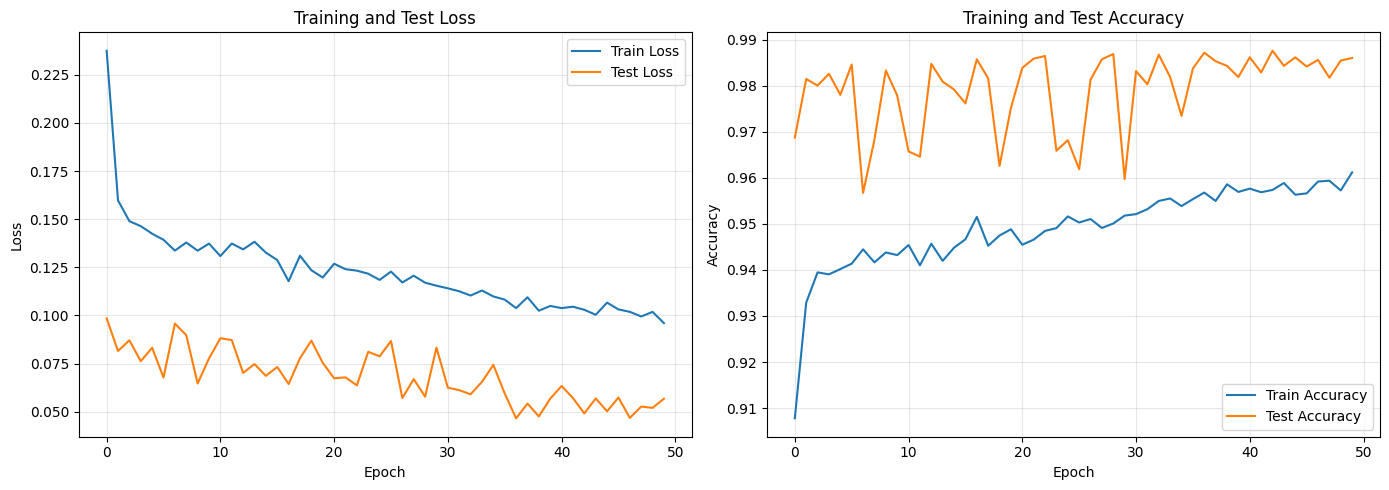

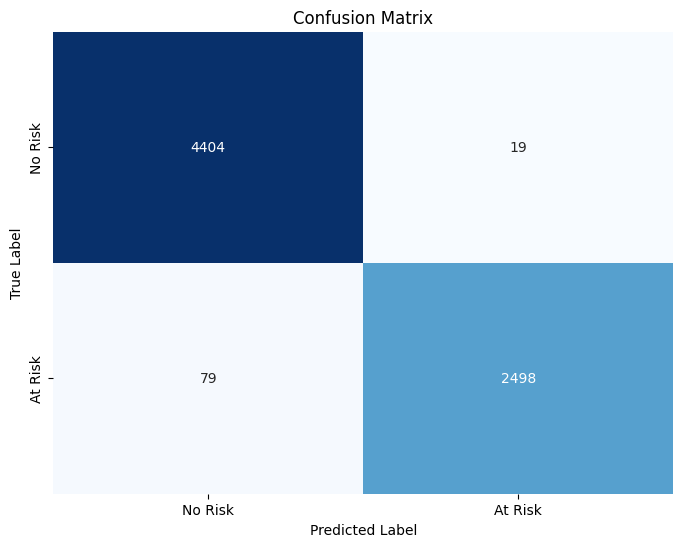

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(test_accs, label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results.png')
print("✓ Saved training plot to 'training_results.png'")

# Confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Risk', 'At Risk'],
            yticklabels=['No Risk', 'At Risk'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
print("✓ Saved confusion matrix to 'confusion_matrix.png'\n")

# ============================================================================
# SAVE MODEL
# ============================================================================
print("="*70)
print("SAVING MODEL")
print("="*70)

os.makedirs('results', exist_ok=True)

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': len(feature_names),
    'accuracy': accuracy
}, 'results/stroke_model.pth')
print("✓ Model saved to 'results/stroke_model.pth'")

# Save scaler
with open('results/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved to 'results/scaler.pkl'")

# Save feature names
with open('results/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print("✓ Feature names saved to 'results/feature_names.pkl'")

print("\n" + "="*70)
print("COMPLETE!")
print("="*70)
print(f"Final Accuracy: {accuracy*100:.2f}%")
print("\nYou can now use this model for predictions!")
print("="*70)

In [21]:
import sys
sys.path.append("/home/mamou/Aws Hanaqtah/Health-Navigator")
from app.workflow.ml_models.numerical_models.stroke_prediction.stroke_predictions import  predict_stroke_risk


data = {
    "age": 22,
    "gender": 1,
    "chest_pain": 1,
    "high_blood_pressure": 0,
    "irregular_heartbeat": 0,
    "shortness_of_breath": 0,
    "fatigue_weakness": 0,
    "dizziness": 0,
    "swelling_edema": 0,
    "neck_jaw_pain": 0,
    "excessive_sweating": 0,
    "persistent_cough": 1,
    "nausea_vomiting": 0,
    "chest_discomfort": 0,
    "cold_hands_feet": 0,
    "snoring_sleep_apnea": 0,
    "anxiety_doom": 0,
}

print(predict_stroke_risk(data))


{'prediction': 0, 'probability': 0.0009}
